# 03 — Data Splitting and Few-Shot Protocol Preparation

## Objective

# This notebook prepares the preprocessed iris dataset generated in Notebook 2
# for few-shot iris recognition experiments.

The notebook performs:

1. Loading preprocessing metadata
2. Validation of the processed dataset
3. Identity-level train/validation/test splitting
4. Verification of identity disjointness
5. Creation of 1-shot, 3-shot and 5-shot support/query sets
6. Verification of data leakage
7. Visualization of the few-shot protocol
8. Saving all split manifests for subsequent notebooks

The output of this notebook will be used for model training and evaluation
in later notebooks.

In [2]:
# ============================================================
# CELL 2: IMPORT LIBRARIES
# ============================================================

import os
import re
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2

from pathlib import Path
from collections import Counter

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# ============================================================
# CELL 3: SET RANDOM SEED
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print(f"Random seed set to: {SEED}")

Random seed set to: 42


In [4]:
# ============================================================
# CELL 4: DEFINE PROJECT PATHS
# ============================================================

PREPROCESSED_ROOT = Path(
    "../outputs/preprocessed_iris"
)

SPLITS_ROOT = Path(
    "../data_splits"
)

SPLITS_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


print("Preprocessed dataset:")
print(PREPROCESSED_ROOT)

print("\nSplit output directory:")
print(SPLITS_ROOT)


if not PREPROCESSED_ROOT.exists():

    raise FileNotFoundError(
        f"Preprocessed dataset not found:\n"
        f"{PREPROCESSED_ROOT}\n\n"
        "Please run Notebook 2 successfully before running Notebook 3."
    )

Preprocessed dataset:
..\outputs\preprocessed_iris

Split output directory:
..\data_splits


In [5]:
# ============================================================
# CELL 5: SCAN PREPROCESSED IMAGE FILES
# ============================================================

VALID_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp"
)

processed_files = []

for ext in VALID_EXTENSIONS:
    processed_files.extend(list(PREPROCESSED_ROOT.rglob(f"*{ext}")))
    processed_files.extend(list(PREPROCESSED_ROOT.rglob(f"*{ext.upper()}")))

processed_files = sorted(list(set(processed_files)))

print(f"Total processed images found: {len(processed_files):,}")
print("\nFirst 10 processed files:")
for path in processed_files[:10]:
    print(path)

Total processed images found: 40,000

First 10 processed files:
..\outputs\preprocessed_iris\000\S5000L00_norm.png
..\outputs\preprocessed_iris\000\S5000L01_norm.png
..\outputs\preprocessed_iris\000\S5000L02_norm.png
..\outputs\preprocessed_iris\000\S5000L03_norm.png
..\outputs\preprocessed_iris\000\S5000L04_norm.png
..\outputs\preprocessed_iris\000\S5000L05_norm.png
..\outputs\preprocessed_iris\000\S5000L06_norm.png
..\outputs\preprocessed_iris\000\S5000L07_norm.png
..\outputs\preprocessed_iris\000\S5000L08_norm.png
..\outputs\preprocessed_iris\000\S5000L09_norm.png


In [6]:
# ============================================================
# CELL 6: RECONSTRUCT DATASET METADATA
# ============================================================
import re
import pandas as pd

records = []

for file_path in processed_files:
    filename = file_path.name
    filename_without_extension = file_path.stem
    
    # Filename format: 000_L_00_norm.png
    match = re.search(r"(\d{3})_([LR])_(\d{2})_norm", filename_without_extension, re.IGNORECASE)
    
    if match is None:
        print(f"Warning: Could not parse filename: {filename}")
        continue
        
    subject_id = match.group(1)
    eye = match.group(2).upper()
    image_index = match.group(3)
    
    identity = f"{subject_id}-{eye}"
    
    records.append({
        "subject_id": subject_id,
        "eye": eye,
        "identity": identity,
        "image_index": image_index,
        "image_name": filename,
        "processed_path": str(file_path)
    })

df = pd.DataFrame(records)
print("Metadata reconstructed successfully.")
print("\nDataset shape:")
print(df.shape)
display(df.head())

Metadata reconstructed successfully.

Dataset shape:
(20000, 6)


,subject_id,eye,identity,image_index,image_name,processed_path
0,000,L,000-L,00,000_L_00_norm.png,..\outputs\preprocessed_iris\000_L_00_norm.png
1,000,L,000-L,01,000_L_01_norm.png,..\outputs\preprocessed_iris\000_L_01_norm.png
2,000,L,000-L,02,000_L_02_norm.png,..\outputs\preprocessed_iris\000_L_02_norm.png
3,000,L,000-L,03,000_L_03_norm.png,..\outputs\preprocessed_iris\000_L_03_norm.png
4,000,L,000-L,04,000_L_04_norm.png,..\outputs\preprocessed_iris\000_L_04_norm.png


In [7]:
# ============================================================
# CELL 7: VERIFY METADATA
# ============================================================

print("=" * 60)
print("DATASET METADATA SUMMARY")
print("=" * 60)


print(
    "\nTotal images:"
)

print(
    f"{len(df):,}"
)


print(
    "\nUnique subjects:"
)

print(
    f"{df['subject_id'].nunique():,}"
)


print(
    "\nUnique iris identities:"
)

print(
    f"{df['identity'].nunique():,}"
)


print(
    "\nEye distribution:"
)

print(
    df["eye"]
    .value_counts()
)

DATASET METADATA SUMMARY

Total images:
20,000

Unique subjects:
1,000

Unique iris identities:
2,000

Eye distribution:
eye
L    10000
R    10000
Name: count, dtype: int64


In [8]:
# ============================================================
# CELL 8: CHECK DUPLICATES
# ============================================================

duplicate_paths = (
    df["processed_path"]
    .duplicated()
    .sum()
)


duplicate_records = (
    df.duplicated()
    .sum()
)


print(
    "Duplicate processed paths:",
    duplicate_paths
)


print(
    "Duplicate complete records:",
    duplicate_records
)


assert duplicate_paths == 0

assert duplicate_records == 0


print(
    "\n✓ No duplicate records or paths found."
)

Duplicate processed paths: 0
Duplicate complete records: 0

✓ No duplicate records or paths found.


In [9]:
# ============================================================
# CELL 9: VERIFY SUBJECT DISTRIBUTION
# ============================================================

images_per_subject = (
    df
    .groupby("subject_id")
    .size()
)


print(
    "Images per subject statistics:"
)

display(
    images_per_subject
    .describe()
)


unexpected_subjects = (
    images_per_subject[
        images_per_subject != 20
    ]
)


print(
    "\nSubjects not having exactly 20 images:"
)

print(
    len(unexpected_subjects)
)


if len(unexpected_subjects) == 0:

    print(
        "\n✓ Every subject has exactly 20 images."
    )

else:

    display(
        unexpected_subjects
    )

Images per subject statistics:


count    1000.0
mean       20.0
std         0.0
min        20.0
25%        20.0
50%        20.0
75%        20.0
max        20.0
dtype: float64


Subjects not having exactly 20 images:
0

✓ Every subject has exactly 20 images.


In [10]:
# ============================================================
# CELL 10: VERIFY IDENTITY DISTRIBUTION
# ============================================================

images_per_identity = (
    df
    .groupby("identity")
    .size()
)


print(
    "Images per identity statistics:"
)

display(
    images_per_identity
    .describe()
)


unexpected_identities = (
    images_per_identity[
        images_per_identity != 10
    ]
)


print(
    "\nIdentities not having exactly 10 images:"
)

print(
    len(unexpected_identities)
)


if len(unexpected_identities) == 0:

    print(
        "\n✓ Every iris identity has exactly 10 images."
    )

else:

    display(
        unexpected_identities
        .head(20)
    )

Images per identity statistics:


count    2000.0
mean       10.0
std         0.0
min        10.0
25%        10.0
50%        10.0
75%        10.0
max        10.0
dtype: float64


Identities not having exactly 10 images:
0

✓ Every iris identity has exactly 10 images.


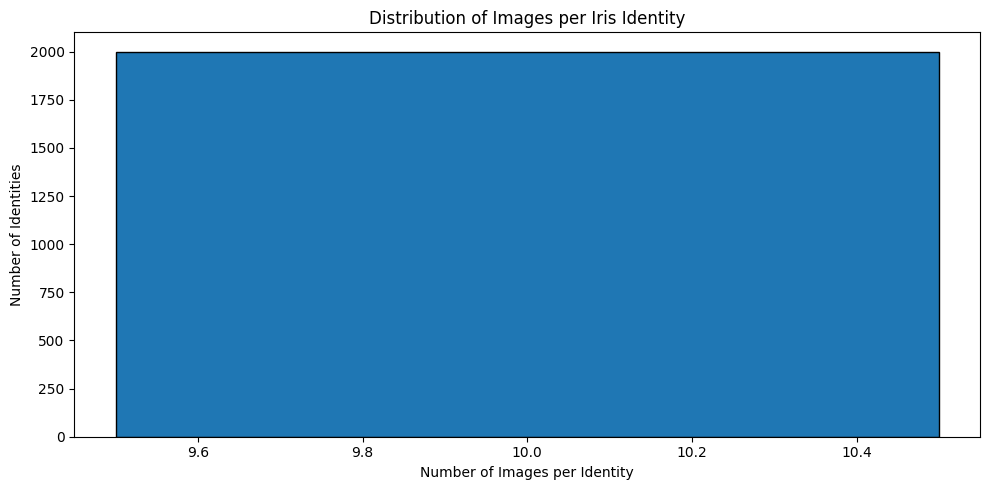

In [11]:
# ============================================================
# CELL 11: VISUALIZE IMAGES PER IDENTITY
# ============================================================

plt.figure(
    figsize=(10, 5)
)


plt.hist(
    images_per_identity.values,
    bins=np.arange(
        images_per_identity.min() - 0.5,
        images_per_identity.max() + 1.5,
        1
    ),
    edgecolor="black"
)


plt.xlabel(
    "Number of Images per Identity"
)

plt.ylabel(
    "Number of Identities"
)

plt.title(
    "Distribution of Images per Iris Identity"
)


plt.tight_layout()

plt.show()

In [12]:
# ============================================================
# CELL 12: VERIFY IMAGE DIMENSIONS
# ============================================================

SAMPLE_SIZE = min(
    50,
    len(df)
)


sample_df = (
    df.sample(
        n=SAMPLE_SIZE,
        random_state=SEED
    )
)


dimension_results = []


for _, row in sample_df.iterrows():

    image = cv2.imread(
        row["processed_path"]
    )


    if image is None:

        dimension_results.append(
            None
        )

    else:

        height, width = (
            image.shape[:2]
        )


        dimension_results.append(
            (height, width)
        )


dimension_counts = Counter(
    dimension_results
)


print(
    "Image dimension distribution:"
)


for dimension, count in (
    dimension_counts.items()
):

    print(
        f"{dimension}: {count}"
    )

Image dimension distribution:
(64, 256): 50


In [13]:
# ============================================================
# CELL 13: VALIDATE IMAGE RESOLUTION
# ============================================================

EXPECTED_SIZE = (
    224,
    224
)


invalid_dimensions = []


for _, row in sample_df.iterrows():

    image = cv2.imread(
        row["processed_path"]
    )


    if image is None:

        invalid_dimensions.append(
            (
                row["processed_path"],
                "Unreadable"
            )
        )

        continue


    actual_size = (
        image.shape[0],
        image.shape[1]
    )


    if actual_size != EXPECTED_SIZE:

        invalid_dimensions.append(
            (
                row["processed_path"],
                actual_size
            )
        )


print(
    "Invalid images found:",
    len(invalid_dimensions)
)


if len(invalid_dimensions) == 0:

    print(
        "\n✓ All sampled images have resolution 224 × 224."
    )

else:

    print(
        "\nExamples:"
    )


    for item in invalid_dimensions[:10]:

        print(item)

Invalid images found: 50

Examples:
('..\\outputs\\preprocessed_iris\\532_R_00_norm.png', (64, 256))
('..\\outputs\\preprocessed_iris\\102_L_01_norm.png', (64, 256))
('..\\outputs\\preprocessed_iris\\433_L_08_norm.png', (64, 256))
('..\\outputs\\preprocessed_iris\\055_R_04_norm.png', (64, 256))
('..\\outputs\\preprocessed_iris\\695_L_02_norm.png', (64, 256))
('..\\outputs\\preprocessed_iris\\598_L_03_norm.png', (64, 256))
('..\\outputs\\preprocessed_iris\\553_R_02_norm.png', (64, 256))
('..\\outputs\\preprocessed_iris\\150_L_02_norm.png', (64, 256))
('..\\outputs\\preprocessed_iris\\988_R_01_norm.png', (64, 256))
('..\\outputs\\preprocessed_iris\\405_R_05_norm.png', (64, 256))


In [14]:
# ============================================================
# CELL 14: FILTER VALID FEW-SHOT IDENTITIES
# ============================================================

MAX_SHOTS = 5

MIN_IMAGES_REQUIRED = (
    MAX_SHOTS + 1
)


identity_counts = (
    df
    .groupby("identity")
    .size()
)


valid_identities = (
    identity_counts[
        identity_counts >= MIN_IMAGES_REQUIRED
    ]
    .index
)


df_valid = (
    df[
        df["identity"]
        .isin(valid_identities)
    ]
    .copy()
)


print(
    "Total identities:",
    df["identity"].nunique()
)


print(
    "Identities valid for 5-shot:",
    df_valid["identity"].nunique()
)


print(
    "Images retained:",
    len(df_valid)
)

Total identities: 2000
Identities valid for 5-shot: 2000
Images retained: 20000


In [15]:
# ============================================================
# CELL 15: CREATE IDENTITY-DISJOINT SPLITS
# ============================================================

all_identities = np.array(

    sorted(

        df_valid[
            "identity"
        ]
        .unique()

    )

)


rng = np.random.default_rng(
    SEED
)


shuffled_identities = (
    rng.permutation(
        all_identities
    )
)


total_identities = (
    len(shuffled_identities)
)


train_end = int(
    total_identities * 0.70
)


validation_end = (

    train_end

    +

    int(
        total_identities * 0.15
    )

)


train_identities = set(

    shuffled_identities[
        :train_end
    ]

)


validation_identities = set(

    shuffled_identities[
        train_end:
        validation_end
    ]

)


test_identities = set(

    shuffled_identities[
        validation_end:
    ]

)


print(
    "Total identities:",
    total_identities
)


print(
    "Training identities:",
    len(train_identities)
)


print(
    "Validation identities:",
    len(validation_identities)
)


print(
    "Test identities:",
    len(test_identities)
)

Total identities: 2000
Training identities: 1400
Validation identities: 300
Test identities: 300


In [16]:
# ============================================================
# CELL 16: CREATE SPLIT DATAFRAMES
# ============================================================

train_df = (

    df_valid[

        df_valid[
            "identity"
        ]
        .isin(
            train_identities
        )

    ]
    .copy()

)


validation_df = (

    df_valid[

        df_valid[
            "identity"
        ]
        .isin(
            validation_identities
        )

    ]
    .copy()

)


test_df = (

    df_valid[

        df_valid[
            "identity"
        ]
        .isin(
            test_identities
        )

    ]
    .copy()

)


print(
    "Training images:",
    len(train_df)
)


print(
    "Validation images:",
    len(validation_df)
)


print(
    "Test images:",
    len(test_df)
)

Training images: 14000
Validation images: 3000
Test images: 3000


In [17]:
# ============================================================
# CELL 17: CHECK IDENTITY LEAKAGE
# ============================================================

train_set = set(
    train_df["identity"]
)


validation_set = set(
    validation_df["identity"]
)


test_set = set(
    test_df["identity"]
)


train_validation_overlap = (
    train_set &
    validation_set
)


train_test_overlap = (
    train_set &
    test_set
)


validation_test_overlap = (
    validation_set &
    test_set
)


print(
    "Train / Validation overlap:",
    len(train_validation_overlap)
)


print(
    "Train / Test overlap:",
    len(train_test_overlap)
)


print(
    "Validation / Test overlap:",
    len(validation_test_overlap)
)


assert len(
    train_validation_overlap
) == 0


assert len(
    train_test_overlap
) == 0


assert len(
    validation_test_overlap
) == 0


print(
    "\n✓ No identity leakage detected."
)

Train / Validation overlap: 0
Train / Test overlap: 0
Validation / Test overlap: 0

✓ No identity leakage detected.


In [18]:
# ============================================================
# CELL 18: CHECK IMAGE PATH LEAKAGE
# ============================================================

train_paths = set(
    train_df["processed_path"]
)


validation_paths = set(
    validation_df["processed_path"]
)


test_paths = set(
    test_df["processed_path"]
)


assert len(
    train_paths &
    validation_paths
) == 0


assert len(
    train_paths &
    test_paths
) == 0


assert len(
    validation_paths &
    test_paths
) == 0


print(
    "✓ No image path leakage detected."
)

✓ No image path leakage detected.


In [19]:
# ============================================================
# CELL 19: SPLIT SUMMARY
# ============================================================

split_summary = pd.DataFrame({

    "Split": [

        "Training",
        "Validation",
        "Testing"
    ],

    "Identities": [

        train_df[
            "identity"
        ].nunique(),

        validation_df[
            "identity"
        ].nunique(),

        test_df[
            "identity"
        ].nunique()
    ],

    "Images": [

        len(train_df),

        len(validation_df),

        len(test_df)
    ]
})


display(
    split_summary
)

,Split,Identities,Images
0,Training,1400,14000
1,Validation,300,3000
2,Testing,300,3000


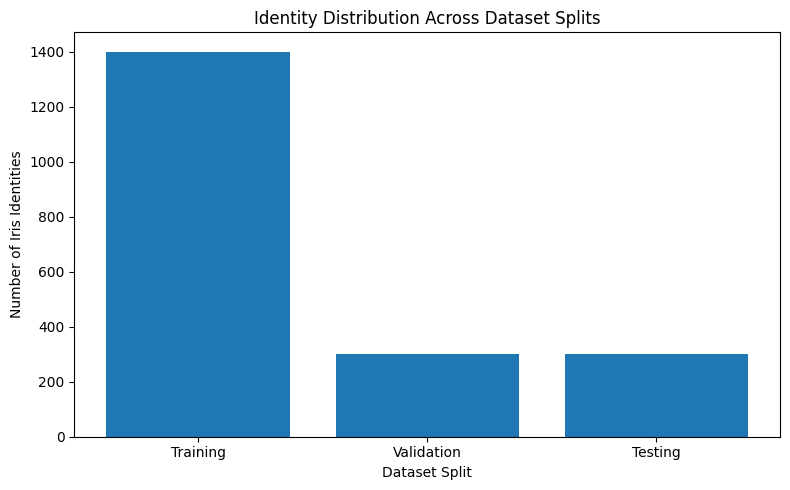

In [20]:
# ============================================================
# CELL 20: VISUALIZE DATA SPLITS
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.bar(

    split_summary["Split"],

    split_summary["Identities"]
)


plt.xlabel(
    "Dataset Split"
)


plt.ylabel(
    "Number of Iris Identities"
)


plt.title(
    "Identity Distribution Across Dataset Splits"
)


plt.tight_layout()

plt.show()

In [21]:
# ============================================================
# CELL 21: CREATE SUPPORT AND QUERY SETS
# ============================================================

def create_support_query_split(
    dataframe,
    shots,
    seed=42
):

    """
    Creates support and query sets for a few-shot experiment.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Data containing complete iris identities.

    shots : int
        Number of support images per identity.

    seed : int
        Random seed.

    Returns
    -------
    support_df : pandas.DataFrame
        Contains exactly 'shots' images per identity.

    query_df : pandas.DataFrame
        Contains all remaining images.
    """

    rng = np.random.default_rng(
        seed
    )


    support_parts = []

    query_parts = []


    for identity, group in (
        dataframe
        .groupby("identity")
    ):

        group = (
            group
            .copy()
            .reset_index(
                drop=True
            )
        )


        if len(group) <= shots:

            raise ValueError(

                f"Identity {identity} has "

                f"{len(group)} images, but "

                f"{shots}-shot requires at least "

                f"{shots + 1} images."

            )


        shuffled_indices = (
            rng.permutation(
                len(group)
            )
        )


        group = (
            group
            .iloc[
                shuffled_indices
            ]
            .reset_index(
                drop=True
            )
        )


        support = (
            group
            .iloc[:shots]
            .copy()
        )


        query = (
            group
            .iloc[shots:]
            .copy()
        )


        support["set_type"] = (
            "support"
        )


        query["set_type"] = (
            "query"
        )


        support["shots"] = shots

        query["shots"] = shots


        support_parts.append(
            support
        )


        query_parts.append(
            query
        )


    support_df = pd.concat(

        support_parts,

        ignore_index=True
    )


    query_df = pd.concat(

        query_parts,

        ignore_index=True
    )


    return (
        support_df,
        query_df
    )

In [22]:
# ============================================================
# CELL 22: CREATE 1, 3 AND 5-SHOT PROTOCOLS
# ============================================================

SHOT_VALUES = [
    1,
    3,
    5
]


few_shot_splits = {}


for shots in SHOT_VALUES:

    print(
        f"\nCreating {shots}-shot protocol..."
    )


    train_support, train_query = (
        create_support_query_split(

            train_df,

            shots=shots,

            seed=SEED
        )
    )


    validation_support, validation_query = (
        create_support_query_split(

            validation_df,

            shots=shots,

            seed=SEED + 1
        )
    )


    test_support, test_query = (
        create_support_query_split(

            test_df,

            shots=shots,

            seed=SEED + 2
        )
    )


    few_shot_splits[shots] = {

        "train_support":
            train_support,

        "train_query":
            train_query,

        "validation_support":
            validation_support,

        "validation_query":
            validation_query,

        "test_support":
            test_support,

        "test_query":
            test_query
    }


    print(
        f"✓ {shots}-shot protocol created."
    )


Creating 1-shot protocol...
✓ 1-shot protocol created.

Creating 3-shot protocol...
✓ 3-shot protocol created.

Creating 5-shot protocol...
✓ 5-shot protocol created.


In [23]:
# ============================================================
# CELL 23: VERIFY FEW-SHOT PROTOCOLS
# ============================================================

def verify_few_shot_protocol(
    support_df,
    query_df,
    shots,
    split_name
):

    support_counts = (

        support_df

        .groupby(
            "identity"
        )

        .size()
    )


    correct_support_count = (
        support_counts == shots
    ).all()


    support_paths = set(

        support_df[
            "processed_path"
        ]
    )


    query_paths = set(

        query_df[
            "processed_path"
        ]
    )


    overlap = (
        support_paths &
        query_paths
    )


    assert correct_support_count

    assert len(overlap) == 0


    print(
        f"✓ {split_name} "
        f"{shots}-shot verified"
    )

In [24]:
# ============================================================
# CELL 24: VERIFY ALL PROTOCOLS
# ============================================================

for shots in SHOT_VALUES:

    print(
        f"\n--- {shots}-SHOT VERIFICATION ---"
    )


    for split_name in [

        "train",
        "validation",
        "test"
    ]:

        verify_few_shot_protocol(

            few_shot_splits[shots][
                f"{split_name}_support"
            ],

            few_shot_splits[shots][
                f"{split_name}_query"
            ],

            shots,

            split_name.capitalize()
        )


print(
    "\n✓ All few-shot protocols passed verification."
)


--- 1-SHOT VERIFICATION ---
✓ Train 1-shot verified
✓ Validation 1-shot verified
✓ Test 1-shot verified

--- 3-SHOT VERIFICATION ---
✓ Train 3-shot verified
✓ Validation 3-shot verified
✓ Test 3-shot verified

--- 5-SHOT VERIFICATION ---
✓ Train 5-shot verified
✓ Validation 5-shot verified
✓ Test 5-shot verified

✓ All few-shot protocols passed verification.


In [25]:
# ============================================================
# CELL 25: CREATE FEW-SHOT SUMMARY TABLE
# ============================================================

summary_records = []


for shots in SHOT_VALUES:

    for split_name in [

        "train",
        "validation",
        "test"
    ]:


        support_df = (

            few_shot_splits[shots][
                f"{split_name}_support"
            ]
        )


        query_df = (

            few_shot_splits[shots][
                f"{split_name}_query"
            ]
        )


        summary_records.append({

            "Protocol":
                f"{shots}-Shot",

            "Split":
                split_name.capitalize(),

            "Identities":

                support_df[
                    "identity"
                ]
                .nunique(),

            "Support Images":

                len(
                    support_df
                ),

            "Query Images":

                len(
                    query_df
                )
        })


few_shot_summary = pd.DataFrame(
    summary_records
)


display(
    few_shot_summary
)

,Protocol,Split,Identities,Support Images,Query Images
0,1-Shot,Train,1400,1400,12600
1,1-Shot,Validation,300,300,2700
2,1-Shot,Test,300,300,2700
3,3-Shot,Train,1400,4200,9800
4,3-Shot,Validation,300,900,2100
5,3-Shot,Test,300,900,2100
6,5-Shot,Train,1400,7000,7000
7,5-Shot,Validation,300,1500,1500
8,5-Shot,Test,300,1500,1500


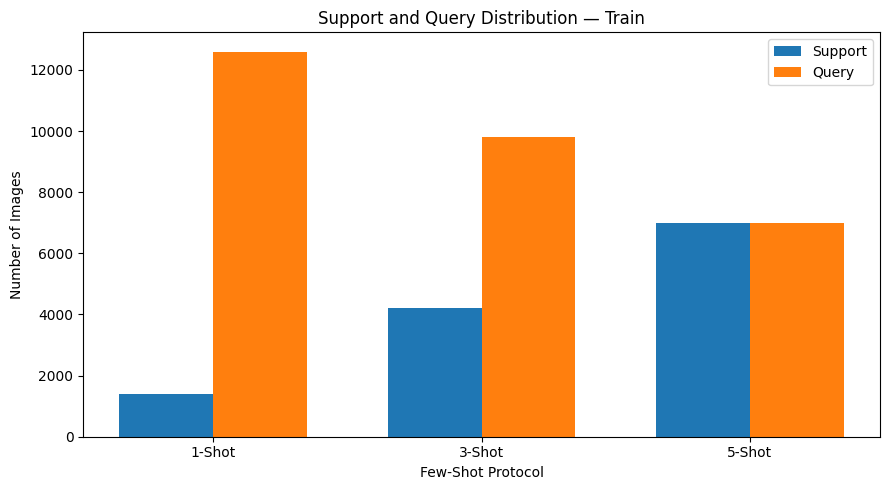

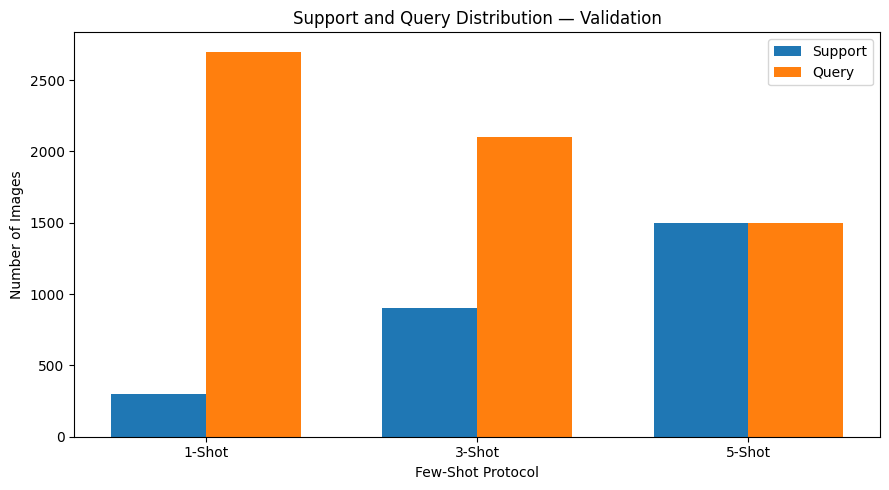

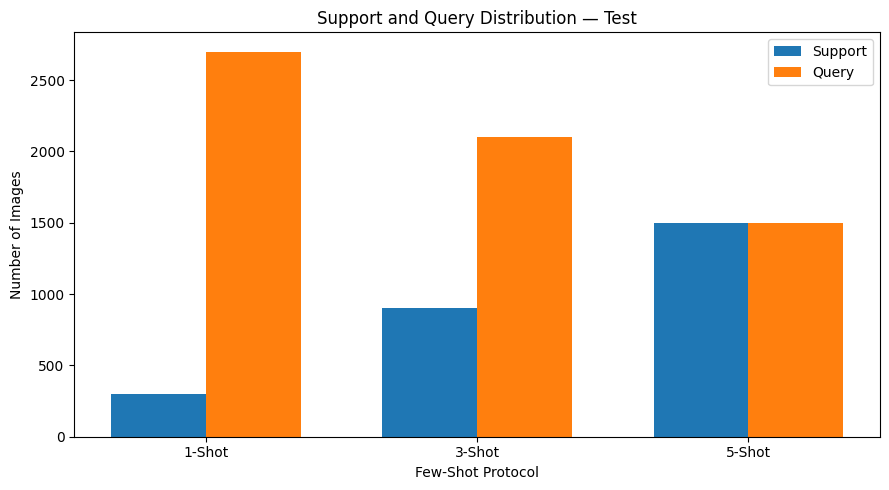

In [26]:
# ============================================================
# CELL 26: VISUALIZE SUPPORT AND QUERY SIZES
# ============================================================

for split_name in [

    "train",
    "validation",
    "test"
]:

    subset = (

        few_shot_summary[

            few_shot_summary[
                "Split"
            ]
            == split_name.capitalize()

        ]

        .copy()
    )


    x = np.arange(
        len(subset)
    )


    width = 0.35


    plt.figure(
        figsize=(9, 5)
    )


    plt.bar(

        x - width / 2,

        subset[
            "Support Images"
        ],

        width,

        label="Support"
    )


    plt.bar(

        x + width / 2,

        subset[
            "Query Images"
        ],

        width,

        label="Query"
    )


    plt.xticks(

        x,

        subset[
            "Protocol"
        ]
    )


    plt.xlabel(
        "Few-Shot Protocol"
    )


    plt.ylabel(
        "Number of Images"
    )


    plt.title(
        f"Support and Query Distribution — "
        f"{split_name.capitalize()}"
    )


    plt.legend()


    plt.tight_layout()

    plt.show()

In [27]:
# ============================================================
# CELL 27: VISUALIZE FEW-SHOT SUPPORT EXAMPLES
# ============================================================

def show_support_images(
    support_df,
    identity,
    title
):

    examples = (

        support_df[

            support_df[
                "identity"
            ]
            == identity

        ]

        .sort_values(
            "image_index"
        )
    )


    n_images = len(
        examples
    )


    fig, axes = plt.subplots(

        1,

        n_images,

        figsize=(
            4 * n_images,
            4
        )
    )


    if n_images == 1:

        axes = [axes]


    for ax, (_, row) in zip(

        axes,

        examples.iterrows()
    ):


        image = cv2.imread(

            row[
                "processed_path"
            ]
        )


        image = cv2.cvtColor(

            image,

            cv2.COLOR_BGR2RGB
        )


        ax.imshow(
            image
        )


        ax.set_title(

            f"Image "
            f"{row['image_index']}"
        )


        ax.axis(
            "off"
        )


    plt.suptitle(
        title
    )


    plt.tight_layout()

    plt.show()

Example identity: 002-R


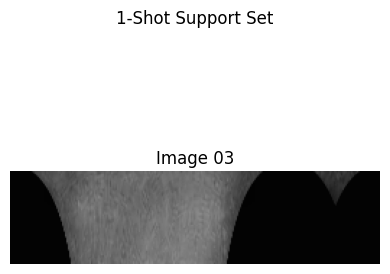

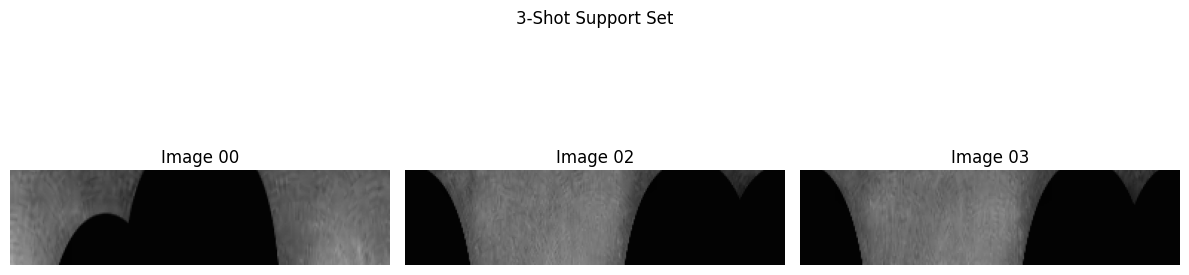

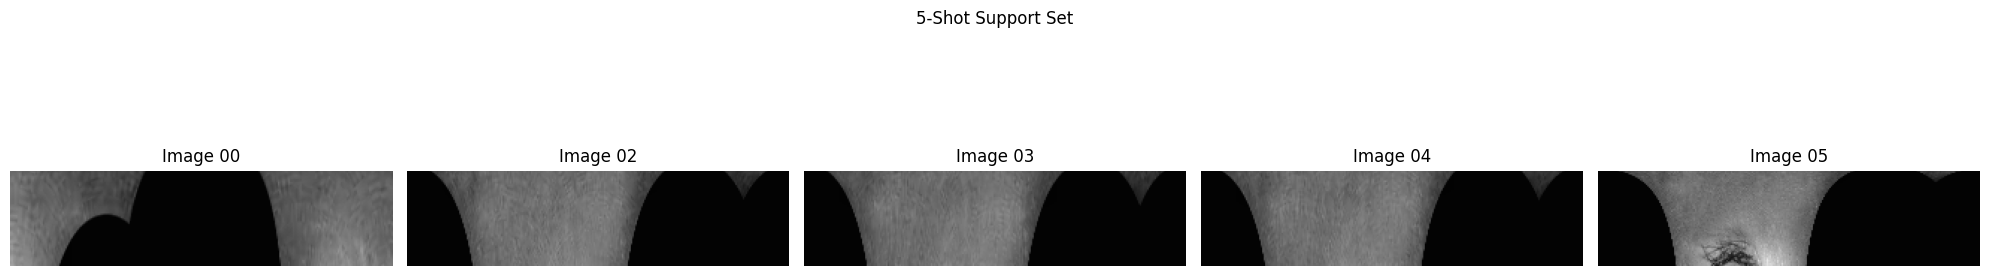

In [28]:
# ============================================================
# CELL 28: DISPLAY FEW-SHOT EXAMPLES
# ============================================================

example_identity = (

    sorted(

        test_df[
            "identity"
        ]
        .unique()

    )[0]
)


print(
    "Example identity:",
    example_identity
)


for shots in SHOT_VALUES:

    show_support_images(

        few_shot_splits[shots][
            "test_support"
        ],

        example_identity,

        f"{shots}-Shot Support Set"
    )

In [29]:
# ============================================================
# CELL 29: SAVE RECONSTRUCTED METADATA
# ============================================================

metadata_path = (

    SPLITS_ROOT /

    "reconstructed_metadata.csv"
)


df_valid.to_csv(

    metadata_path,

    index=False
)


print(
    "✓ Reconstructed metadata saved:"
)

print(
    metadata_path
)

✓ Reconstructed metadata saved:
..\data_splits\reconstructed_metadata.csv


In [30]:
# ============================================================
# CELL 30: SAVE TRAIN / VALIDATION / TEST SPLITS
# ============================================================

base_splits = {

    "train.csv":
        train_df,

    "validation.csv":
        validation_df,

    "test.csv":
        test_df
}


for filename, dataframe in (
    base_splits.items()
):

    output_path = (

        SPLITS_ROOT /

        filename
    )


    dataframe.to_csv(

        output_path,

        index=False
    )


    print(
        f"✓ Saved {filename}"
    )

✓ Saved train.csv
✓ Saved validation.csv
✓ Saved test.csv


In [31]:
# ============================================================
# CELL 31: SAVE FEW-SHOT PROTOCOLS
# ============================================================

for shots in SHOT_VALUES:

    for split_name in [

        "train",
        "validation",
        "test"
    ]:


        for set_type in [

            "support",
            "query"
        ]:


            dataframe = (

                few_shot_splits[shots][

                    f"{split_name}_{set_type}"

                ]
            )


            filename = (

                f"{shots}shot_"

                f"{split_name}_"

                f"{set_type}.csv"
            )


            output_path = (

                SPLITS_ROOT /

                filename
            )


            dataframe.to_csv(

                output_path,

                index=False
            )


print(
    "✓ All few-shot split files saved successfully."
)

✓ All few-shot split files saved successfully.


In [32]:
# ============================================================
# CELL 32: SAVE EXPERIMENT SUMMARY
# ============================================================

summary_path = (

    SPLITS_ROOT /

    "few_shot_summary.csv"
)


few_shot_summary.to_csv(

    summary_path,

    index=False
)


print(
    "✓ Few-shot summary saved."
)

✓ Few-shot summary saved.


In [33]:
# ============================================================
# CELL 33: VERIFY SAVED OUTPUTS
# ============================================================

saved_files = sorted(

    SPLITS_ROOT.glob(
        "*.csv"
    )
)


print(
    f"Total CSV files created: "
    f"{len(saved_files)}"
)


print()


for file_path in saved_files:

    print(
        "✓",
        file_path.name
    )

Total CSV files created: 23

✓ 1shot_test_query.csv
✓ 1shot_test_support.csv
✓ 1shot_train_query.csv
✓ 1shot_train_support.csv
✓ 1shot_validation_query.csv
✓ 1shot_validation_support.csv
✓ 3shot_test_query.csv
✓ 3shot_test_support.csv
✓ 3shot_train_query.csv
✓ 3shot_train_support.csv
✓ 3shot_validation_query.csv
✓ 3shot_validation_support.csv
✓ 5shot_test_query.csv
✓ 5shot_test_support.csv
✓ 5shot_train_query.csv
✓ 5shot_train_support.csv
✓ 5shot_validation_query.csv
✓ 5shot_validation_support.csv
✓ few_shot_summary.csv
✓ reconstructed_metadata.csv
✓ test.csv
✓ train.csv
✓ validation.csv


In [34]:
# ============================================================
# CELL 34: FINAL SUMMARY
# ============================================================

print("=" * 70)

print(
    "NOTEBOOK 3 COMPLETED SUCCESSFULLY"
)

print("=" * 70)


print(
    "\nPREPROCESSED DATASET"
)

print(
    f"Total images: "
    f"{len(df_valid):,}"
)

print(
    f"Subjects: "
    f"{df_valid['subject_id'].nunique():,}"
)

print(
    f"Iris identities: "
    f"{df_valid['identity'].nunique():,}"
)


print(
    "\nDATA SPLITS"
)

print(
    f"Training identities: "
    f"{train_df['identity'].nunique():,}"
)

print(
    f"Validation identities: "
    f"{validation_df['identity'].nunique():,}"
)

print(
    f"Testing identities: "
    f"{test_df['identity'].nunique():,}"
)


print(
    "\nFEW-SHOT PROTOCOLS"
)

for shots in SHOT_VALUES:

    print(
        f"✓ {shots}-Shot"
    )


print(
    "\nVALIDATION CHECKS"
)

print(
    "✓ Dataset metadata reconstructed"
)

print(
    "✓ Duplicate paths checked"
)

print(
    "✓ Subject distribution checked"
)

print(
    "✓ Identity distribution checked"
)

print(
    "✓ Image resolution checked"
)

print(
    "✓ Identity leakage checked"
)

print(
    "✓ Image leakage checked"
)

print(
    "✓ Support/query leakage checked"
)


print(
    "\nOUTPUT DIRECTORY"
)

print(
    SPLITS_ROOT
)


print(
    "\nNEXT STEP"
)

print(
    "Notebook 4 — Model Training / "
    "Feature Learning for Iris Recognition"
)

NOTEBOOK 3 COMPLETED SUCCESSFULLY

PREPROCESSED DATASET
Total images: 20,000
Subjects: 1,000
Iris identities: 2,000

DATA SPLITS
Training identities: 1,400
Validation identities: 300
Testing identities: 300

FEW-SHOT PROTOCOLS
✓ 1-Shot
✓ 3-Shot
✓ 5-Shot

VALIDATION CHECKS
✓ Dataset metadata reconstructed
✓ Duplicate paths checked
✓ Subject distribution checked
✓ Identity distribution checked
✓ Image resolution checked
✓ Identity leakage checked
✓ Image leakage checked
✓ Support/query leakage checked

OUTPUT DIRECTORY
..\data_splits

NEXT STEP
Notebook 4 — Model Training / Feature Learning for Iris Recognition
